# COMPOSITE Rule - SAA 기반 Grid Search 튜닝

목적함수: J_hat(w) = (1/N) sum[ w1 * Makespan/mk_ref + w2 * QV/qv_ref ]  (최소화)

- w = (alpha, beta, gamma, delta) - COMPOSITE rule의 Index Policy 선형결합 가중치 (4차원)
  - α: Process Time (짧을수록 우선, SPT 일관성)
  - β: slack_qtime (qtime 위험도)
  - γ: c_transition (다음 transition 위험 가중치)
  - δ: setup time
- 정규화(mk_ref, qv_ref): **utopia point** — SPTSSU의 평균 makespan, MIN_QTIME의 평균 QV
- 가중치 weight(w1, w2): 기본 1.0, 1.0
- c_transition: 데이터 기반 결정론적 위험도 `(1/qtime_limit) × frequency` → max 정규화
- CRN: replication별 고정 seed -> w 간 공정 비교

전제: DOWN_ACTIVE=True - J_samples 분산 발생으로 t-test/SAA bias가 의미를 가진다.

구성: 1.설정 → 2.evaluator → 3.grid 탐색 → 4.baseline paired t-test → 5.SAA bias → 6.BO

## 1. 환경 설정 및 데이터 로드

In [1]:
import os
import sys
import time
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# 노트북이 tuning/ 아래에 있으므로 프로젝트 루트를 sys.path에 추가
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from utils import DataLoader
from tuning.saa_evaluator import SAAEvaluator

plt.rcParams['font.family'] = ['Malgun Gothic', 'AppleGothic', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

BASE_DATA_PATH = os.path.join(PROJECT_ROOT, 'data')
data = DataLoader(BASE_DATA_PATH).load_all_data()
print(f"Jobs: {len(data['jobs'])} / Operations: {len(data['operations'])} / Machines: {len(data['machines'])}")

Jobs: 60 / Operations: 870 / Machines: 60


## 2. SAA Evaluator 초기화

초기화 시 두 가지를 수행한다.

1. **transition 위험 가중치 테이블 (deterministic, data-driven)**:
   `risk[A->B] = (1 / qtime_limit[A->B]) × frequency[A->B]` 를 최댓값 정규화 → [0,1] 테이블.
   짧은 qtime + 자주 일어나는 transition일수록 위험. policy 독립이고 stochastic noise도 없다.
   priority 모듈에 주입되어 c_transition 항이 이 값을 조회한다.
2. **목적함수 정규화 기준 (rule-based 산술평균)**:
   - `result_compare.ipynb`가 6개 baseline rule(`random, FIFO, SPT, LPT, MIN_QTIME, SPTSSU`)을 각 30회 시뮬레이션한 결과의 **산술평균**으로 `mk_ref`, `qv_ref`를 산출.
   - 결과는 `data/normalization_ref.json`에 저장돼 있으며 본 셀이 그대로 로드해 evaluator에 주입한다.
   - 의미: J<1.0이면 후보가 *"평균적 baseline rule들보다 우월"*. GA 등 다른 최적화기와 같은 분모를 공유해 직접 비교 가능.

In [ ]:
import json

OBJ_WEIGHTS = (1.0, 1.0)       # (w1, w2): Makespan 항 : QV 항 = 1:1
DOWN_ACTIVE = True             # True면 Machine.down 활성 -> J_samples 분산 발생 (t-test/SAA bias 의미)

# --- 정규화 기준(mk_ref, qv_ref) 로드 ---
# result_compare.ipynb가 6개 baseline rule × 30 run의 산술평균으로 산출해
# data/normalization_ref.json에 저장한 값을 그대로 사용한다.
# (SAA 내부에서 utopia-point baseline을 재계산하지 않는다 -> rule-based / GA 와 분모 통일)
REF_PATH = os.path.join(BASE_DATA_PATH, 'normalization_ref.json')
with open(REF_PATH, 'r', encoding='utf-8') as f:
    ref_payload = json.load(f)
MK_REF = float(ref_payload['mk_ref'])
QV_REF = float(ref_payload['qv_ref'])
print(f"loaded {REF_PATH}")
print(f"  method       = {ref_payload.get('method')}")
print(f"  baseline rules = {ref_payload.get('rules')}")
print(f"  n_runs         = {ref_payload.get('n_runs')}")
print(f"  mk_ref = {MK_REF:.1f}   qv_ref = {QV_REF:.1f}\n")

evaluator = SAAEvaluator(
    data,
    obj_weights=OBJ_WEIGHTS,
    base_seed=0,
    down_active=DOWN_ACTIVE,
    pm_active=False,
    mk_ref=MK_REF,
    qv_ref=QV_REF,
)
_s = evaluator.summary()
print('transition 위험 가중치 테이블 (data-driven):')
for t, v in sorted(_s['transition_risk'].items(), key=lambda x: -x[1]):
    print(f'  {t}: {v:.4f}')
print(f"\nmk_ref = {_s['mk_ref']:.1f}")
print(f"qv_ref = {_s['qv_ref']:.1f}")
print(f"obj_weights (w1, w2) = {_s['obj_weights']}")
print(f"DOWN_ACTIVE = {DOWN_ACTIVE}")

## 3. Grid Search — Dirichlet 균등 격자

각 weight를 0/K, 1/K, ..., K/K로 두고 **합=1인 조합만** 채택하는 simplex 위의 균등 격자(Dirichlet lattice).

**근거**

- COMPOSITE는 candidate 내 min-max 정규화 후 선형결합 → 절대 스케일이 아니라 **상대 비율**만 의미가 있다. `c·(α,β,γ,δ)`는 같은 dispatch를 만든다.
- 따라서 sum=1 simplex로 자유도를 하나 줄여도 일반성을 잃지 않는다.
- log/linear 임의성 없이 **균등 분할**이라 후보 정당화가 명확하고, 0(해당 항 끄기)과 corner(특정 항만 사용)가 자연 포함된다.

**점 수 공식**: C(K+DIM-1, DIM-1) — DIM=4, K=5 → 56점.

| K | 분할 단계 | 점 수 |
|---|---|---|
| 4 | {0, .25, .5, .75, 1} | 35 |
| **5** | **{0, .2, .4, .6, .8, 1}** | **56** (현 기본) |
| 6 | {0, 1/6, ..., 1} | 84 |

**탐색 비용** = 점 수 × N_RUNS. K=5, N_RUNS=10 → 560 runs.

### 4개 항

| 항 | 의미 | 부호 |
|---|---|---|
| α (PT) | process time | 짧을수록 우선 (SPT 일관성) |
| β (slack) | remain_qtime | 작을수록 위험 → 우선 |
| γ (c_transition) | 다음 transition 위험도 | 위험할수록 우선 (음수 처리) |
| δ (setup) | setup time | 짧을수록 우선 |

> **계수가 0으로 수렴하는 항**이 나오면 → 해당 항 정의를 다른 신호로 교체(예: α를 다시 WAIT_TIME / CRITICAL_RATIO 등)하는 방향으로 다시 sweep을 돌릴 수 있다. 본 noteook은 그 단계별 가설 검증의 첫 번째 라운드(α=PT)다.

- 장시간 실행 시 JupyterLab 권장 (VS Code Jupyter 소켓 타임아웃 회피)

In [3]:
# --- Dirichlet 균등 격자 (sum=1 simplex 위의 K분할 격자) ---
# 각 weight를 0/K, 1/K, ..., K/K 중 하나로 두고, 합이 1(= K/K)인 조합만 채택.
K = 6   # 격자 해상도. 키우면 점 수 증가 (K=3:20, K=4:35, K=5:56)
DIM = 4

grid = []
for c in product(range(K + 1), repeat=DIM):
    if sum(c) == K:
        grid.append(tuple(round(x / K, 6) for x in c))

ALPHA_GRID = sorted({w[0] for w in grid})
BETA_GRID  = sorted({w[1] for w in grid})
GAMMA_GRID = sorted({w[2] for w in grid})
DELTA_GRID = sorted({w[3] for w in grid})

N_RUNS = 10   # stochastic 시나리오: 각 w당 replication 수. CRN으로 w간 비교는 공정.

print(f"K={K}, DIM={DIM}")
print(f"각 축 후보값: {ALPHA_GRID}")
print(f"grid 점 수: {len(grid)}  ->  총 시뮬레이션 {len(grid) * N_RUNS}회")


K=6, DIM=4
각 축 후보값: [0.0, 0.166667, 0.333333, 0.5, 0.666667, 0.833333, 1.0]
grid 점 수: 84  ->  총 시뮬레이션 840회


In [4]:
# --- grid 탐색 실행 ---
records = []
t0 = time.time()
for i, w in enumerate(grid):
    res = evaluator.evaluate(w, n_runs=N_RUNS)
    records.append({
        'alpha': w[0], 'beta': w[1], 'gamma': w[2], 'delta': w[3],
        'J_hat': res['J_hat'], 'se': res['se'],
        'makespan': res['makespan_mean'],
        'qtime_violation': res['qtime_violation_mean'],
    })
    if (i + 1) % 10 == 0 or i + 1 == len(grid):
        print(f"  [{i+1}/{len(grid)}]  elapsed {time.time()-t0:.1f}s")

grid_df = pd.DataFrame(records).sort_values('J_hat').reset_index(drop=True)
print(f"\n총 소요: {time.time()-t0:.1f}s")
print(f"best w = (a={grid_df.iloc[0]['alpha']:.3f}, b={grid_df.iloc[0]['beta']:.3f}, "
      f"g={grid_df.iloc[0]['gamma']:.3f}, d={grid_df.iloc[0]['delta']:.3f})   "
      f"J_hat={grid_df.iloc[0]['J_hat']:.4f}")

print(f"\n[Top 5]")
print(grid_df.head(5).to_string(index=False))

  [10/84]  elapsed 300.0s
  [20/84]  elapsed 488.4s
  [30/84]  elapsed 653.8s
  [40/84]  elapsed 837.6s
  [50/84]  elapsed 982.1s
  [60/84]  elapsed 1154.4s
  [70/84]  elapsed 1310.5s
  [80/84]  elapsed 1463.6s
  [84/84]  elapsed 1521.6s

총 소요: 1521.6s
best w = (a=0.000, b=0.500, g=0.167, d=0.333)   J_hat=1.7664

[Top 5]
 alpha     beta    gamma    delta    J_hat       se     makespan  qtime_violation
   0.0 0.500000 0.166667 0.333333 1.766372 0.124108 12624.773737      5115.613378
   0.0 0.666667 0.000000 0.333333 1.807057 0.132891 12611.893642      5382.826771
   0.0 0.333333 0.500000 0.166667 1.830625 0.133792 12607.517350      5536.105246
   0.0 0.833333 0.000000 0.166667 1.833933 0.127819 12561.167843      5580.115039
   0.0 0.666667 0.166667 0.166667 1.836173 0.126293 12565.076024      5592.556112


In [5]:
# --- best_w 추출 ---
best_row = grid_df.iloc[0]
best_w = tuple(round(float(best_row[k]), 3) for k in ['alpha', 'beta', 'gamma', 'delta'])
best = best_row   # SAA bias / BO 시각화 셀에서 참조

print(f"best w = {best_w}")
print(f"  J_hat = {round(best_row['J_hat'], 3)}  (se={round(best_row['se'], 3)})")
print(f"  makespan = {round(best_row['makespan'], 3)}   qtime_violation = {round(best_row['qtime_violation'], 3)}")

# 0으로 수렴한 항 점검 → 다음 라운드에서 항 정의 교체 후보를 시사
zero_terms = [name for name, v in zip(['α(PT)','β(slack)','γ(trans)','δ(setup)'], best_w) if v <= 1e-9]
if zero_terms:
    print(f"\n⚠ best에서 0으로 수렴한 항: {zero_terms}")
    print("  → 해당 항의 신호가 약하거나 다른 항과 정보가 겹친다는 신호.")
    print("    다음 라운드에서 정의 교체(예: α=PT → α=WAIT_TIME 또는 CRITICAL_RATIO) 고려.")

best w = (0.0, 0.5, 0.167, 0.333)
  J_hat = 1.766  (se=0.124)
  makespan = 12624.774   qtime_violation = 5115.613

⚠ best에서 0으로 수렴한 항: ['α(PT)']
  → 해당 항의 신호가 약하거나 다른 항과 정보가 겹친다는 신호.
    다음 라운드에서 정의 교체(예: α=PT → α=WAIT_TIME 또는 CRITICAL_RATIO) 고려.


## 3. COMPOSITE best_w + 기존 rule 비교 — Paired t-test

grid best_w와 baseline rule들을 **같은 CRN seed 집합**으로 비교한다.

In [6]:
# --- COMPOSITE best_w + baseline을 같은 CRN N_TEST=30으로 paired t-test ---
N_TEST = 30
COMPARE_RULES = ['FIFO', 'SPT', 'LPT', 'MIN_QTIME', 'SPTSSU']

J_samples = {}

# COMPOSITE best_w
J_samples['COMPOSITE'] = evaluator.evaluate(best_w, n_runs=N_TEST)['J_samples']

# baseline rules
for rule in COMPARE_RULES:
    J_samples[rule] = evaluator.evaluate_rule(rule, n_runs=N_TEST)['J_samples']

# 요약 표
rows = []
for label, js in J_samples.items():
    rows.append({
        'rule': label,
        'J_mean': js.mean(),
        'J_se': js.std(ddof=1) / np.sqrt(len(js)),
    })
summary_df = pd.DataFrame(rows).sort_values('J_mean').reset_index(drop=True)
summary_df[['J_mean', 'J_se']] = summary_df[['J_mean', 'J_se']].round(4)
print(f"[N_TEST={N_TEST} CRN — 같은 seed 집합에서 평가]")
print(summary_df.to_string(index=False))

best_baseline = min(COMPARE_RULES, key=lambda r: J_samples[r].mean())
print(f"\n최강 baseline = {best_baseline}  (J_mean = {J_samples[best_baseline].mean():.4f})")

def _paired(a, b, label_a, label_b):
    diff = a - b
    print(f"\n[Paired t-test]  {label_a}  vs  {label_b}  (n={len(diff)})")
    print(f"  평균 차이 = {diff.mean():+.4f}   std = {diff.std(ddof=1):.4f}")
    if np.isclose(diff.std(ddof=1), 0.0):
        verdict = '동등(분산 없음)' if np.isclose(diff.mean(), 0.0) else (
                  '개선(결정론적 차이)' if diff.mean() < 0 else '악화(결정론적 차이)')
        print(f"  [결정론적] 판정: {verdict}")
        return
    t, p_two = stats.ttest_rel(a, b)
    p_one = p_two / 2 if t < 0 else 1.0 - p_two / 2
    print(f"  t = {t:.4f}   양측 p = {p_two:.4g}   단측 p = {p_one:.4g}")
    if p_one < 0.01: v = f'{label_a}이 매우 유의미하게 개선 (p<0.01)'
    elif p_one < 0.05: v = f'{label_a}이 유의미하게 개선 (p<0.05)'
    elif p_one < 0.10: v = '경향성만 (p<0.10)'
    else: v = '유의미한 차이 아님'
    print(f"  판정: {v}")

# COMPOSITE vs 최강 baseline
_paired(J_samples['COMPOSITE'], J_samples[best_baseline],
        'COMPOSITE', best_baseline)

print(f"\n>>> 채택: w={best_w}   (BO 단계에 인계)")

[N_TEST=30 CRN — 같은 seed 집합에서 평가]
     rule  J_mean   J_se
COMPOSITE  1.8536 0.0996
MIN_QTIME  2.0400 0.1190
      LPT  3.3990 0.0965
      SPT  5.4860 0.2272
     FIFO  7.3575 0.2106
   SPTSSU  8.8552 0.1841

최강 baseline = MIN_QTIME  (J_mean = 2.0400)

[Paired t-test]  COMPOSITE  vs  MIN_QTIME  (n=30)
  평균 차이 = -0.1864   std = 0.3115
  t = -3.2786   양측 p = 0.002712   단측 p = 0.001356
  판정: COMPOSITE이 매우 유의미하게 개선 (p<0.01)

>>> 채택: w=(0.0, 0.5, 0.167, 0.333)   (BO 단계에 인계)


## 4. SAA Bias 관찰

SAA 이론(최소화 문제): 표본 평균으로 구한 v_N = min_w J_hat_N(w)는 아래로 편향된다.

E[v_N] <= E[v_(N+1)] <= v*

즉 N이 작을수록 grid 최소 J_hat이 낙관적(편향), N이 커지면 진짜 최적값 v*에 점차 수렴한다. 이를 관찰하려면:

- **DOWN_ACTIVE=True 전제**: 시나리오가 stochastic이어야 N에 따라 표본 평균이 변한다.
- **외부 평균**: 같은 N으로 *여러 다른 seed 묶음*을 뽑아 v_N의 분포 자체를 본다. 한 seed 묶음만 보면 단일 표본이라 편향 정도를 추정 못 함.
- **계산 비용**: grid 점수 × sum(N) × OUTER 회 시뮬레이션. N 키우면 빠르게 부담스러워지므로 grid를 좁힌다.

**BIAS_GRID는 메인 grid와 동일한 Dirichlet simplex(sum=1, 각 ∈[0,1]) 위에서 정의**한다. 메인 K=5(56점)는 bias 외부 평균을 OUTER번 반복하기엔 비싸므로 **K_BIAS=3(20점)** 으로 coarse화한다.

In [7]:
# --- SAA bias 관찰: 외부 OUTER번 반복하여 E[v_N]을 추정 ---
# 메인 grid와 동일한 Dirichlet simplex 위에서 BIAS_GRID 구성 (K_BIAS=3 -> 20점)
from tuning.saa_evaluator import _makespan, _qtime_violation

K_BIAS = 3
BIAS_GRID = []
for c in product(range(K_BIAS + 1), repeat=DIM):
    if sum(c) == K_BIAS:
        BIAS_GRID.append(tuple(round(x / K_BIAS, 6) for x in c))

BIAS_N_LIST = [2, 5, 10]
OUTER = 3
N_MAX = max(BIAS_N_LIST)

# Incremental averaging:
#   각 (outer, w)마다 N_MAX회만 시뮬레이션하고, 앞 n개의 부분평균으로 N=2,5,10의
#   J_hat을 동시에 산출한다. seed 묶음이 nested(앞 2개 ⊂ 앞 5개 ⊂ 전체 10개)
#   이므로 독립 실행과 통계적으로 동치. 비용: |grid| × N_MAX × OUTER (sum(N) 대신).
print(f"BIAS_GRID 점 수: {len(BIAS_GRID)} (K_BIAS={K_BIAS}, simplex)")
print(f"비용(incremental): {len(BIAS_GRID)} x N_MAX x OUTER = "
      f"{len(BIAS_GRID) * N_MAX * OUTER}회 시뮬레이션")

# v_n_outer[n] = OUTER 반복에서 산출한 v_N 리스트
v_n_outer = {n: [] for n in BIAS_N_LIST}

orig_base = evaluator.base_seed
t0 = time.time()
for o in range(OUTER):
    evaluator.base_seed = orig_base + o * 10_000
    # j_min_per_n[n] = min over w of partial-mean J_hat with first n seeds
    j_min_per_n = {n: float('inf') for n in BIAS_N_LIST}
    for w in BIAS_GRID:
        evaluator._apply_params(w)
        seeds = evaluator._seed_list(N_MAX)
        js = []
        for s in seeds:
            log_df = evaluator._run_once('COMPOSITE', s)
            js.append(evaluator._objective(_makespan(log_df),
                                           _qtime_violation(log_df)))
        for n in BIAS_N_LIST:
            jh_n = float(np.mean(js[:n]))
            if jh_n < j_min_per_n[n]:
                j_min_per_n[n] = jh_n
    for n in BIAS_N_LIST:
        v_n_outer[n].append(j_min_per_n[n])
    print(f"  [outer {o+1}/{OUTER}] elapsed {time.time()-t0:.1f}s")
evaluator.base_seed = orig_base

bias_records = []
for n in BIAS_N_LIST:
    v_arr = np.asarray(v_n_outer[n])
    bias_records.append({
        'N': n,
        'E[v_N]': v_arr.mean(),
        'se(v_N)': v_arr.std(ddof=1) / np.sqrt(OUTER),
        'v_outer': v_arr,
    })
    print(f"N={n:3d}  E[v_N] = {v_arr.mean():.4f}  +/- {v_arr.std(ddof=1)/np.sqrt(OUTER):.4f}  "
          f"(OUTER={OUTER}회 평균)")

bias_df = pd.DataFrame([{k: r[k] for k in ['N', 'E[v_N]', 'se(v_N)']} for r in bias_records])
bias_df = bias_df.round(4)
bias_df

BIAS_GRID 점 수: 20 (K_BIAS=3, simplex)
비용(incremental): 20 x N_MAX x OUTER = 600회 시뮬레이션
  [outer 1/3] elapsed 385.2s
  [outer 2/3] elapsed 889.1s
  [outer 3/3] elapsed 1389.8s
N=  2  E[v_N] = 1.9578  +/- 0.0744  (OUTER=3회 평균)
N=  5  E[v_N] = 1.8339  +/- 0.0623  (OUTER=3회 평균)
N= 10  E[v_N] = 1.8525  +/- 0.0859  (OUTER=3회 평균)


,N,E[v_N],se(v_N)
0,2,1.9578,0.0744
1,5,1.8339,0.0623
2,10,1.8525,0.0859


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

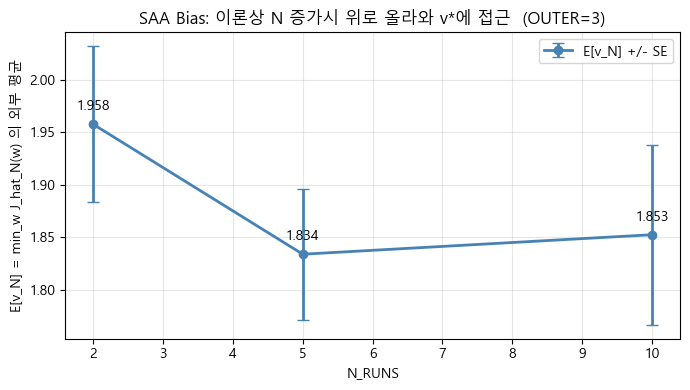

E[v_N] 단조 증가: NO - OUTER가 작아 노이즈에 가려졌을 수 있음. OUTER를 키워보라
가장 큰 N(10)에서 E[v_N] = 1.8525  -> 이 값이 v* 추정치에 가장 가깝다.


In [8]:
# --- bias 거동 시각화 (OUTER 평균 +/- SE) ---
fig, ax = plt.subplots(figsize=(7, 4))
Ns = bias_df['N'].values
means = bias_df['E[v_N]'].values
ses = bias_df['se(v_N)'].values
ax.errorbar(Ns, means, yerr=ses, fmt='o-', color='steelblue', lw=2, capsize=4, label='E[v_N] +/- SE')
for n, m in zip(Ns, means):
    ax.annotate(f"{m:.3f}", (n, m), textcoords='offset points', xytext=(0, 10), ha='center')
ax.set_xlabel('N_RUNS')
ax.set_ylabel('E[v_N] = min_w J_hat_N(w) 의 외부 평균')
ax.set_title(f'SAA Bias: 이론상 N 증가시 위로 올라와 v*에 접근  (OUTER={OUTER})')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

mono = all(means[i] <= means[i+1] + 1e-9 for i in range(len(means) - 1))
print(f"E[v_N] 단조 증가: {'YES (이론과 일치)' if mono else 'NO - OUTER가 작아 노이즈에 가려졌을 수 있음. OUTER를 키워보라'}")
print(f"가장 큰 N({Ns[-1]})에서 E[v_N] = {means[-1]:.4f}  -> 이 값이 v* 추정치에 가장 가깝다.")


## 5. Bayesian Optimization (연속 공간 미세 탐색)

grid search는 simplex 위의 K분할 격자점만 평가한다. 격자 사이의 진짜 최적은 놓칠 수 있다. 여기서는 **채택 후보(`best_alpha_term`)의 best_w 주변**을 연속 공간으로 정의하고 `gp_minimize`로 미세 탐색한다.

In [10]:
from skopt import gp_minimize
from skopt.space import Real
from skopt.plots import plot_convergence

# best_w 주변으로 탐색 공간 정의. 경계에 붙어 있으면 그쪽으로 더 넓게 연다.
def _make_space(best_w, grids):
    space = []
    names = ['alpha', 'beta', 'gamma', 'delta']
    for v, g, name in zip(best_w, grids, names):
        g_lo, g_hi = min(g), max(g)
        half = (g_hi - g_lo) / 2 if g_hi > g_lo else max(1.0, abs(v))
        lo = v - half
        hi = v + half
        # 경계 부착 시 그 방향 확장
        if v <= g_lo + 1e-9:
            lo = max(0.0, v - half)
            hi = v + 2 * half
        elif v >= g_hi - 1e-9:
            lo = max(0.0, v - 2 * half)
            hi = v + 2 * half
        lo = max(0.0, lo)
        if hi <= lo:
            hi = lo + 1.0
        space.append(Real(lo, hi, name=name))
    return space

GRIDS = [ALPHA_GRID, BETA_GRID, GAMMA_GRID, DELTA_GRID]
space = _make_space(best_w, GRIDS)
for s in space:
    print(f"  {s.name}: [{s.low:.3f}, {s.high:.3f}]")


ModuleNotFoundError: No module named 'skopt'

In [ ]:
# --- BO 실행 ---
N_CALLS = 40       # 총 평가 횟수 (initial + GP 제안)
N_INITIAL = 10     # 초기 random sampling
N_BO = N_RUNS      # 각 w 평가에 쓸 replication 수 (grid와 동일하게)

print(f"BO (grid best w = {best_w})")

bo_history = []

def _bo_objective(w_list):
    w = tuple(float(x) for x in w_list)
    jh = evaluator.evaluate(w, n_runs=N_BO)['J_hat']
    bo_history.append({'w': w, 'J_hat': jh})
    return jh

t0 = time.time()
bo_result = gp_minimize(
    _bo_objective,
    dimensions=space,
    n_calls=N_CALLS,
    n_initial_points=N_INITIAL,
    acq_func='EI',
    random_state=0,
)
print(f"BO 소요: {time.time()-t0:.1f}s  ({N_CALLS}회 평가)")

# scale-invariance를 이용해 BO 결과를 sum=1 simplex로 정규화 (grid best와 같은 척도)
bo_raw = tuple(float(x) for x in bo_result.x)
s = sum(bo_raw)
bo_best_w = tuple(round(x / s, 3) for x in bo_raw) if s > 1e-9 else tuple(round(x, 3) for x in bo_raw)
bo_best_J = round(float(bo_result.fun), 3)
print(f"BO 최적 w (raw)        = {tuple(round(x, 3) for x in bo_raw)}  (sum={s:.3f})")
print(f"BO 최적 w (simplex 정규화) = (a={bo_best_w[0]}, b={bo_best_w[1]}, g={bo_best_w[2]}, d={bo_best_w[3]})")
print(f"J_hat = {bo_best_J}")

In [ ]:
# --- grid best vs BO best 비교 ---
res_grid = evaluator.evaluate(best_w, n_runs=N_BO)
res_bo = evaluator.evaluate(bo_best_w, n_runs=N_BO)

cmp_rows = [
    {'source': 'grid best', 'w': best_w,
     'J_hat': res_grid['J_hat'], 'makespan': res_grid['makespan_mean'],
     'qtime_violation': res_grid['qtime_violation_mean']},
    {'source': 'BO best',   'w': bo_best_w,
     'J_hat': res_bo['J_hat'], 'makespan': res_bo['makespan_mean'],
     'qtime_violation': res_bo['qtime_violation_mean']},
]
cmp_df = pd.DataFrame(cmp_rows)
num_cols = ['J_hat', 'makespan', 'qtime_violation']
cmp_df[num_cols] = cmp_df[num_cols].round(3)
print(cmp_df.to_string(index=False))

delta_J = res_grid['J_hat'] - res_bo['J_hat']
print(f"\nJ_hat 개선폭 (grid - BO) = {round(delta_J, 3)}")
print('=> BO가 격자 사이의 더 나은 점을 찾았다.' if delta_J > 1e-6
      else '=> grid best와 사실상 동등 (격자가 이미 유망 영역을 잡았다는 신호).')

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

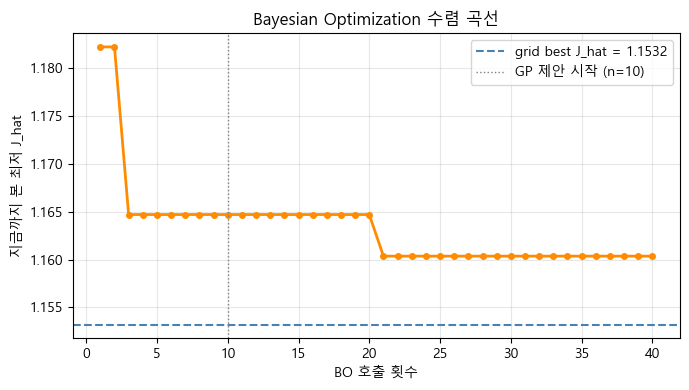

In [ ]:
# --- 수렴 곡선: BO가 호출 i까지 본 최저 J_hat ---
fig, ax = plt.subplots(figsize=(7, 4))
running_min = np.minimum.accumulate([h['J_hat'] for h in bo_history])
ax.plot(range(1, len(running_min) + 1), running_min, 'o-', color='darkorange', lw=2, markersize=4)
ax.axhline(best['J_hat'], color='steelblue', ls='--', lw=1.5, label=f"grid best J_hat = {best['J_hat']:.4f}")
ax.axvline(N_INITIAL, color='gray', ls=':', lw=1, label=f'GP 제안 시작 (n={N_INITIAL})')
ax.set_xlabel('BO 호출 횟수')
ax.set_ylabel('지금까지 본 최저 J_hat')
ax.set_title('Bayesian Optimization 수렴 곡선')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
